# 1. Linear SVM

<font color='red'>Assignment:</font> Load the data in "../data/svm.csv" into a DataFrame.

In [63]:
import pandas as pd
df = pd.read_csv('svm.csv')
df.head()
df.shape

(200, 3)

In [64]:
X = df[['x1', 'x2']]

<font color='red'>Assignment:</font> Import **SVC** from sklearn, and train a SVM classifier using **Linear Kernel** to predict y with **x1** and **x2**. No need to hold out a test set this time.

In [65]:
from sklearn.svm import SVC

# Create an instance of the SVC classifier with a linear kernel
svm_classifier = SVC(kernel='linear')

x = df[['x1', 'x2']]
y = df['y']
# Fit the SVM classifier to the data
svm_classifier.fit(x, y)

# The classifier is now trained and ready for predictions

SVC(kernel='linear')

<font color='red'>Assignment:</font> Find out the **support vectors** and plot them together with data points.

In [66]:
# Get the support vectors
support_vectors = svm_classifier.support_vectors_
support_vectors

array([[ 1.55624094,  1.11479029],
       [ 1.20372171,  1.40495343],
       [ 1.49379259,  1.14332924],
       [ 1.44935822,  1.20500473],
       [ 1.66855686,  0.01866655],
       [ 1.41860816,  0.08048487],
       [ 0.02501113,  1.48362746],
       [-0.04344945,  1.45086578]])

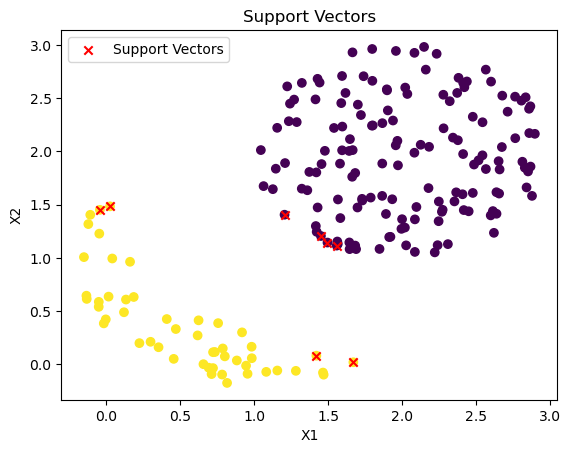

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Plot the data points
plt.scatter(x['x1'], x['x2'], c=y)

# Plot the support vectors
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], c='r', marker='x', label='Support Vectors')

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Support Vectors')
plt.legend()
plt.show()







<font color='red'>Question:</font> What are support vectors?

support vectors are the data points that define the margins and influence the position of the decision boundary in an SVM classifier. They are the critical instances that contribute to the classification process and are essential for the overall performance of the SVM model.

<font color='red'>Question:</font> How many support vectors in this model? Where do they locate?

In [68]:
num_support_vectors = svm_classifier.n_support_
num_support_vectors

array([4, 4], dtype=int32)

<font color='red'>Assignment:</font> Change hyper parameter **C** and find out how the number and locations of support vectors are affected.

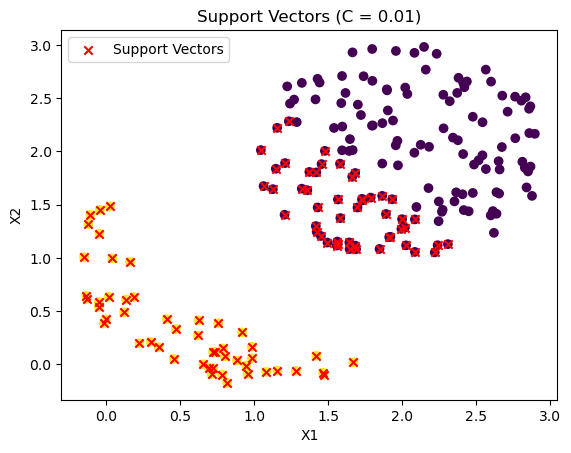

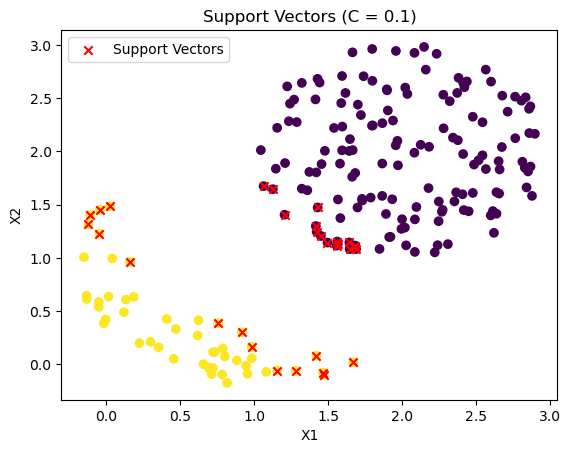

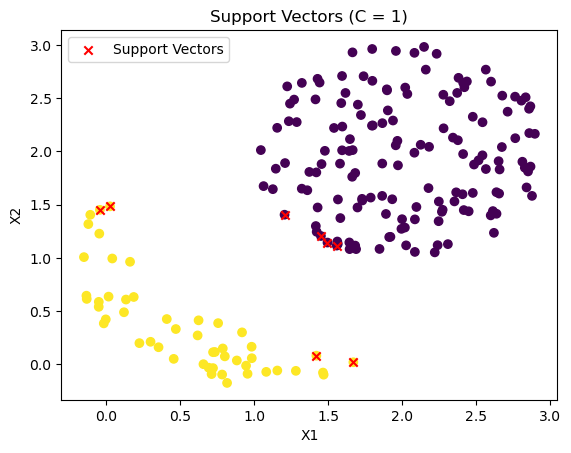

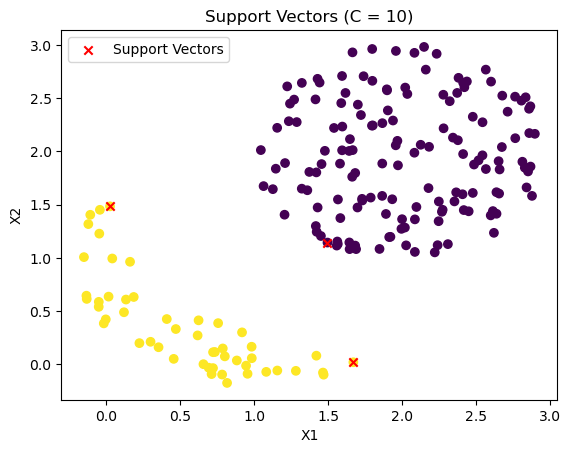

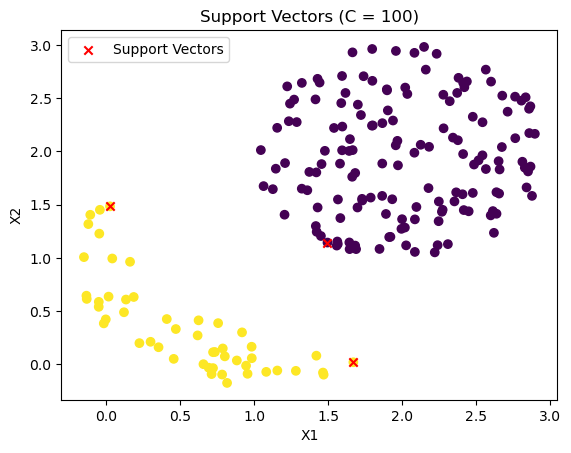

In [69]:
# Define the range of C values to test
C_values = [0.01, 0.1, 1, 10, 100]

# Iterate over each C value
for C in C_values:
    # Create an instance of the SVC classifier with a linear kernel and the desired C value
    svm_classifier = SVC(kernel='linear', C=C)

    # Fit the SVM classifier to the data
    svm_classifier.fit(x, y)

    # Get the support vectors from the classifier
    support_vectors = svm_classifier.support_vectors_

    # Plot the data points
    plt.scatter(x['x1'], x['x2'], c=y)

    # Plot the support vectors
    plt.scatter(support_vectors[:, 0], support_vectors[:, 1], c='r', marker='x', label='Support Vectors')

    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title(f'Support Vectors (C = {C})')
    plt.legend()
    plt.show()





<font color='red'>Question:</font> When **C** is relatively small (e.g. 0.01), how many support vectors in positive and negative classes, respectively? Do you see any problem with that?

In [70]:
svm_classifier = SVC(kernel='linear', C=0.01)

    # Fit the SVM classifier to the data
svm_classifier.fit(x, y)

    # Get the support vectors from the classifier
num_support_vectors = svm_classifier.n_support_

num_support_vectors_positive = num_support_vectors[1]  # Number of support vectors for positive class
num_support_vectors_negative = num_support_vectors[0]  # Number of support vectors for negative class

print("Number of support vectors for positive class:", num_support_vectors_positive)
print("Number of support vectors for negative class:", num_support_vectors_negative)
    

Number of support vectors for positive class: 50
Number of support vectors for negative class: 50


<font color='red'>Assignment:</font> Balance the classes (using **class_weight**), re-train the model, and find out the change of support vector numbers in positive and negative classes.

In [71]:
from sklearn.svm import SVC

# Create an instance of the SVC classifier with a linear kernel
svm_classifier = SVC(kernel='linear')

x = df[['x1', 'x2']]
y = df['y']

# Fit the balanced SVM classifier to the data
svm_classifier.fit(x, y)

# Get the number of support vectors for each class
num_support_vectors = svm_classifier.n_support_

# Assuming the classes are labeled as 0 and 1, you can access the count for each class as follows:
num_support_vectors_positive = num_support_vectors[1]  # Number of support vectors for positive class
num_support_vectors_negative = num_support_vectors[0]  # Number of support vectors for negative class

print("Number of support vectors for positive class (balanced):", num_support_vectors_positive)
print("Number of support vectors for negative class (balanced):", num_support_vectors_negative)




Number of support vectors for positive class (balanced): 4
Number of support vectors for negative class (balanced): 4


In [72]:
from sklearn.svm import SVC

# Create an instance of the SVC classifier with a linear kernel
svm_classifier = SVC(kernel='linear',C=0.01)

x = df[['x1', 'x2']]
y = df['y']

# Count the number of samples in each class
num_positive_samples = (y == 1).sum()
num_negative_samples = (y == 0).sum()

# Calculate the class weights to balance the classes
class_weight = {1: num_negative_samples / num_positive_samples, 0: 1.0}

# Create a new instance of the SVC classifier with balanced class weights
svm_classifier_balanced = SVC(kernel='linear', class_weight=class_weight)

# Fit the balanced SVM classifier to the data
svm_classifier_balanced.fit(x, y)

# Get the number of support vectors for each class
num_support_vectors_balanced = svm_classifier_balanced.n_support_

# Assuming the classes are labeled as 0 and 1, you can access the count for each class as follows:
num_support_vectors_positive_balanced = num_support_vectors_balanced[1]  # Number of support vectors for positive class
num_support_vectors_negative_balanced = num_support_vectors_balanced[0]  # Number of support vectors for negative class

print("Number of support vectors for positive class (balanced):", num_support_vectors_positive_balanced)
print("Number of support vectors for negative class (balanced):", num_support_vectors_negative_balanced)








Number of support vectors for positive class (balanced): 2
Number of support vectors for negative class (balanced): 4


<font color='red'>Question:</font> Is SVM sensitive to base rate? Why?

<font color='red'>Question:</font> What is a hyperplane?

<font color='red'>Question:</font> What is the optimal hyperplane for a SVM model?

<font color='red'>Question:</font> What is the difference between hard margin and soft margin? Which margin was adopted in the above model?

<font color='red'>Question:</font> What is hinge loss?

<font color='red'>Question:</font> What is the difference between SVM and Logistic Regression? What are the pros and cons of these two algorithm?


<font color='red'>Question:</font> Given a data set with many columns and a relatively small amount of rows, which algorithm could be better? SVM or Logistic Regression?

# 2. Non-Linear SVM

**Example:** SVM visualization class

In [83]:
from sklearn.svm import SVC

# Create an instance of the SVC classifier with a linear kernel
svm_classifier = SVC(kernel='linear')

x = df[['x1', 'x2']]
y = df['y']

# Count the number of samples in each class
num_positive_samples = (y == 1).sum()
num_negative_samples = (y == 0).sum()

# Calculate the class weights to balance the classes
class_weight = {1: num_negative_samples / num_positive_samples, 0: 1.0}

# Create a new instance of the SVC classifier with balanced class weights
model = SVC(kernel='linear', class_weight=class_weight)

# Fit the balanced SVM classifier to the data
model.fit(x, y)


SVC(class_weight={0: 1.0, 1: 3.0}, kernel='linear')

In [84]:
import matplotlib.pylab as plt
import numpy as np
%matplotlib inline


class svm_visualization(object):
    
    def __init__(self, model, data):
        self.model = model
        self.data = data
        xrange = df.x1.max() - df.x1.min()
        yrange = df.x2.max() - df.x2.min()
        self.xmin = df.x1.min() - 0.1 * xrange
        self.xmax = df.x1.max() + 0.1 * xrange
        self.ymin = df.x2.min() - 0.1 * yrange
        self.ymax = df.x2.max() + 0.1 * yrange
        
    def show(self):
        self.plot_contour()
        self.plot_data()
        self.plot_sv()
        try:
            self.plot_boundry()
        except:
            print('Warning: No boundry is available!')
        plt.xlim(self.xmin, self.xmax)
        plt.ylim(self.ymin, self.ymax)

    def plot_data(self):
        df = self.data
        plt.scatter(df[df.y==0]['x1'], df[df.y==0]['x2'], alpha=0.5)
        plt.scatter(df[df.y==1]['x1'], df[df.y==1]['x2'], alpha=0.5)
        return plt
    
    def plot_sv(self):
        indices = self.model.support_
        svs = self.model.support_vectors_
        plt.scatter(svs[:, 0], svs[:, 1], facecolors='none', edgecolors='r')
        return plt
    
    def plot_boundry(self):
        w = self.model.coef_[0]
        a = -w[0] / w[1]
        x = np.linspace(self.xmin, self.xmax)
        y = a * x - (self.model.intercept_[0]) / w[1]
        plt.plot(x, y, ls='--', c='k')
        return plt
    
    def plot_contour(self):
        x = np.linspace(self.xmin, self.xmax, 30)
        y = np.linspace(self.ymin, self.ymax, 30)
        Y, X = np.meshgrid(y, x)
        xy = np.vstack([X.ravel(), Y.ravel()]).T
        Z = self.model.decision_function(xy).reshape(X.shape)
        z_bound = 3*max(abs(Z.min()), abs(Z.max()))
        plt.contourf(X, Y, Z, 50, cmap='bwr', vmin=-z_bound, vmax=z_bound)
        plt.colorbar()
        return plt

**Example:** Visualize linear SVM model. The dash line (only appears in linear models) indicates the decision boundry, and the contour indicates how confidently the prediction of a class.

/Users/junlingren/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


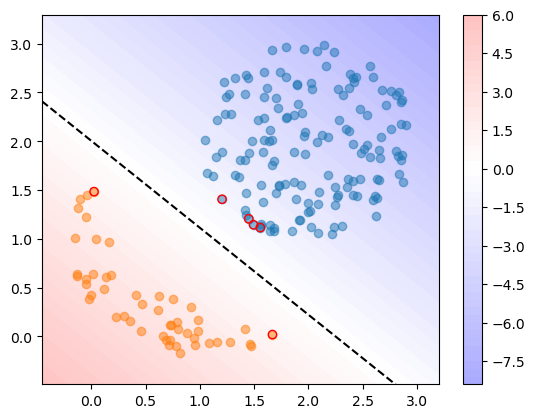

In [85]:
sv = svm_visualization(model, df)
sv.show()

<font color='red'>Assignment:</font> Try **rbf** and **poly** kernels.

/Users/junlingren/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


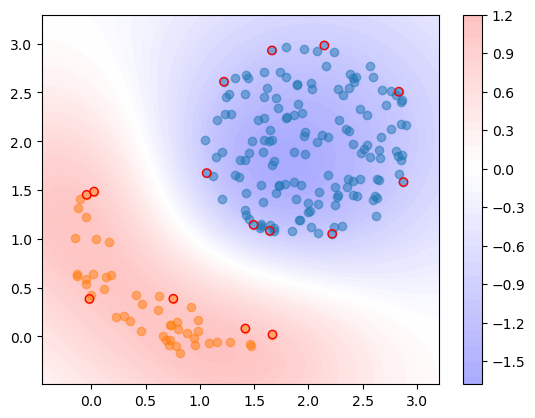

In [89]:
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np

# Create an instance of the SVC classifier with the RBF kernel
rbf_model = SVC(kernel='rbf')
rbf_model.fit(x, y)


# Create an instance of the svm_visualization class for the RBF kernel
rbf_sv = svm_visualization(rbf_model, df)
rbf_sv.show()







/Users/junlingren/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


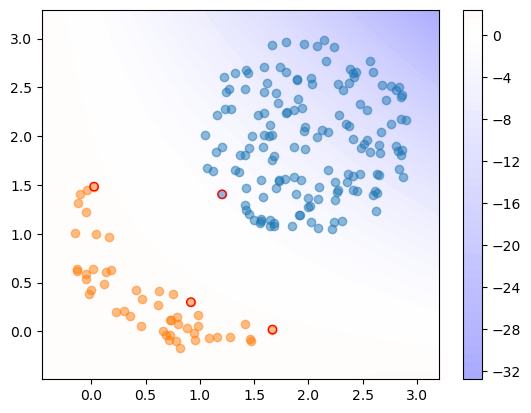

In [87]:
# Create an instance of the SVC classifier with the polynomial kernel
poly_model = SVC(kernel='poly')
poly_model.fit(x, y)

# Create an instance of the svm_visualization class for the polynomial kernel
poly_sv = svm_visualization(poly_model, df)
poly_sv.show()


<font color='red'>Question:</font> How do these two kernels work? Where do the support vectors locate, respectively?